# Drought duration

This how-to guide demonstrates how to download, process, and visualize drought duration data for a specific NUTS2 region using the Climate Data Store (CDS) API. We'll retrieve both historical reanalysis and climate projection data to assess drought hazard for the region EL64 (Central Greece).

**What you'll learn:**
- Download drought duration data from the European Climate Data Explorer (ECDE) using CDSAPI
- Process historical and projection drought data for a specific region
- Extract and visualize drought timeseries for multiple ensemble members
- Create spatial maps of drought duration
- Save processed timeseries to CSV files for further analysis

**Dataset:** [European Climate Data Explorer - Climate Indicators](https://cds.climate.copernicus.eu/datasets/sis-ecde-climate-indicators)

**Region:** EL64 (Central Greece, NUTS2 level)

## Setup and configuration

First, we'll import the necessary libraries and set up our region of interest.

In [2]:
import os
import zipfile
import cdsapi
import glob
from pathlib import Path
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from functools import partial

# Set working directory (adjust as needed)
os.chdir("/home/nejk/code/drought_exposure")
print(f"Working directory: {os.getcwd()}")

Working directory: /etc/ecmwf/nfs/dh2_home_a/nejk/code/drought_exposure


In [3]:
# Define region of interest
admin_id = "EL64"  # Central Greece NUTS2 region

# Set up data directories
data_dir = Path("./data")
ecde_dir = data_dir / "ecde"
hist_dir = ecde_dir / "historical"
proj_dir = ecde_dir / "projections"
output_dir = data_dir / "EL64" / "drought_hazard"

# Create directories if they don't exist
for directory in [ecde_dir, hist_dir, proj_dir, output_dir]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Data will be saved to: {ecde_dir}")
print(f"Output files will be saved to: {output_dir}")

Data will be saved to: data/ecde
Output files will be saved to: data/EL64/drought_hazard


### Helper function to unzip downloaded data

The CDS API downloads data as zip files. We need a function to extract and rename the NetCDF files.

In [4]:
def unzip_ecde_data(zipfile_path):
    """
    Unzip ECDE data downloaded from CDS and rename to .nc extension.
    
    Parameters:
    -----------
    zipfile_path : Path or str
        Path to the zip file to extract
    """
    zipfile_path = Path(zipfile_path)
    
    with zipfile.ZipFile(zipfile_path, 'r') as zip_ref:
        names = zip_ref.namelist()
        zip_ref.extractall(zipfile_path.parent)
        
        for name in names:
            if name.split(".")[-1] == "nc":
                # Rename the extracted file to match the zip filename
                nc_path = zipfile_path.with_suffix('.nc')
                os.rename(zipfile_path.parent / name, nc_path)
                print(f"  Extracted: {nc_path.name}")
            else:
                # Remove non-NetCDF files
                os.remove(zipfile_path.parent / name)
    
    # Remove the zip file after extraction
    os.remove(zipfile_path)
    print(f"  Removed: {zipfile_path.name}")

### Load NUTS region boundaries

We'll load the NUTS region shapefile to visualize our region of interest.

In [7]:
# Read NUTS shapefiles
regions_dir = data_dir / 'regions'
nuts_shp = regions_dir / 'NUTS_RG_20M_2024_4326' / 'NUTS_RG_20M_2024_4326.shp'
nuts_gdf = gpd.read_file(nuts_shp)

# Select the region of interest
sel_gdf = nuts_gdf[nuts_gdf['NUTS_ID'] == admin_id]
print(f"Region: {sel_gdf['NUTS_NAME'].values[0]}")
print(f"NUTS ID: {admin_id}")
print(f"Country: {sel_gdf['CNTR_CODE'].values[0]}")
print(f"Bounding box: {sel_gdf.geometry.total_bounds}")

Region: Στερεά Ελλάδα
NUTS ID: EL64
Country: EL
Bounding box: [21.39637798 37.98898161 24.67199242 39.27219519]


## Download historical drought duration data

We'll download historical drought duration data from the ECDE reanalysis dataset. To avoid long queues in the CDS, we download the data in smaller chunks (e.g., decade by decade).

> ⏱️ **Time needed:** Each download takes approximately 2-5 minutes depending on CDS queue.

In [6]:
# Define time periods to download in chunks to avoid long queues
time_chunks = [
    (1979, 1990),
    (1991, 2000),
    (2001, 2010),
    (2011, 2023)
]

# Download historical data
print("Downloading historical drought duration data...")
print("=" * 60)

hist_files = []

for start_year, end_year in time_chunks:
    years = [str(y) for y in range(start_year, end_year + 1)]
    hist_zipfile = hist_dir / f"drought_duration_nuts2_hist_{start_year}_{end_year}.zip"
    hist_ncfile = hist_zipfile.with_suffix('.nc')
    
    # Skip if already downloaded
    if hist_ncfile.exists():
        print(f"Years {start_year}-{end_year}: Already exists, skipping download")
        hist_files.append(hist_ncfile)
        continue
    
    print(f"Years {start_year}-{end_year}: Downloading...")
    
    dataset = "sis-ecde-climate-indicators"
    request = {
        "variable": ["duration_of_meteorological_droughts"],
        "origin": "reanalysis",
        "temporal_aggregation": ["yearly"],
        "spatial_aggregation": "regional_layer",
        "regional_layer": ["nuts_level_2"],
        "year": years
    }
    
    try:
        client = cdsapi.Client()
        client.retrieve(dataset, request).download(str(hist_zipfile))
        unzip_ecde_data(hist_zipfile)
        hist_files.append(hist_ncfile)
        print(f"  ✓ Download complete for {start_year}-{end_year}")
    except Exception as e:
        print(f"  ✗ Error downloading {start_year}-{end_year}: {e}")

print("=" * 60)
print(f"Historical data download complete! Downloaded {len(hist_files)} files.")

Years 1979-1990: Downloading...


2026-02-03 13:39:56,510 INFO Request ID is 1a4a9a9e-ff98-4541-9721-f4888300a57d
2026-02-03 13:39:56,542 INFO status has been updated to accepted
2026-02-03 13:40:09,911 INFO status has been updated to successful


d174aadc01d62ff8226220218d5f726a.zip:   0%|          | 0.00/252k [00:00<?, ?B/s]

  Extracted: drought_duration_nuts2_hist_1979_1990.nc
  Removed: drought_duration_nuts2_hist_1979_1990.zip
  ✓ Download complete for 1979-1990
Years 1991-2000: Downloading...


2026-02-03 13:40:10,411 INFO Request ID is 0c080e35-6518-41f9-bf30-145c18edd150
2026-02-03 13:40:10,445 INFO status has been updated to accepted
2026-02-03 13:40:23,845 INFO status has been updated to successful


...

2026-02-03 13:40:45,289 INFO Request ID is 7d8b209f-0129-4419-938c-01a3e20beb7a
2026-02-03 13:40:45,302 INFO status has been updated to accepted


  Extracted: drought_duration_nuts2_hist_2001_2010.nc
  Removed: drought_duration_nuts2_hist_2001_2010.zip
  ✓ Download complete for 2001-2010
Years 2011-2023: Downloading...


2026-02-03 13:40:58,785 INFO status has been updated to successful


5b9a08403360ca15734faccd5230e270.zip:   0%|          | 0.00/252k [00:00<?, ?B/s]

  Extracted: drought_duration_nuts2_hist_2011_2023.nc
  Removed: drought_duration_nuts2_hist_2011_2023.zip
  ✓ Download complete for 2011-2023
Historical data download complete! Downloaded 4 files.


## Download drought projections

We'll download climate projection data for multiple Global Climate Models (GCMs), Regional Climate Models (RCMs), scenarios (RCPs), and ensemble members. To avoid overwhelming the CDS queue, we download one combination at a time.

> ⏱️ **Time needed:** This can take several hours depending on the number of model combinations and CDS queue times. Each download takes approximately 2-5 minutes.

### Define model combinations to download

We'll download a subset of available model combinations. You can adjust these lists based on your needs.

In [8]:
# Define model combinations
# Note: Not all combinations are available in the dataset

gcms = ["ec_earth", "hadgem2_es", "ipsl_cm5a_mr", "mpi_esm_lr", "noresm1_m"]
rcms = ["cclm4_8_17", "hirham5", "racmo22e", "rca4", "wrf381p"]
rcps = ["rcp4_5", "rcp8_5"]
enss = ["r12i1p1", "r1i1p1", "r3i1p1"]

# Time periods for projections (download in chunks)
proj_time_chunks = [
    (2006, 2025),
    (2026, 2050),
    (2051, 2075),
    (2076, 2100)
]

print(f"Model combinations to attempt:")
print(f"  GCMs: {len(gcms)}")
print(f"  RCMs: {len(rcms)}")
print(f"  RCPs: {len(rcps)}")
print(f"  Ensemble members: {len(enss)}")
print(f"  Time periods: {len(proj_time_chunks)}")
print(f"  Maximum possible downloads: {len(gcms) * len(rcms) * len(rcps) * len(enss) * len(proj_time_chunks)}")
print(f"\nNote: Not all combinations are available in the dataset.")

Model combinations to attempt:
  GCMs: 5
  RCMs: 5
  RCPs: 2
  Ensemble members: 3
  Time periods: 4
  Maximum possible downloads: 600

Note: Not all combinations are available in the dataset.


In [9]:
# Download projection data
print("\nDownloading drought projection data...")
print("=" * 60)

proj_files = []
download_count = 0
skip_count = 0
error_count = 0

for gcm in gcms:
    for rcm in rcms:
        for rcp in rcps:
            for ens in enss:
                for start_year, end_year in proj_time_chunks:
                    
                    years = [str(y) for y in range(start_year, end_year + 1)]
                    
                    # Create filename
                    proj_zipfile = proj_dir / f"drought_duration_nuts2_{gcm}_{rcm}_{rcp}_{ens}_{start_year}_{end_year}.zip"
                    proj_ncfile = proj_zipfile.with_suffix('.nc')
                    
                    # Skip if already downloaded
                    if proj_ncfile.exists():
                        skip_count += 1
                        proj_files.append(proj_ncfile)
                        continue
                    
                    model_info = f"{gcm}/{rcm}/{rcp}/{ens} ({start_year}-{end_year})"
                    print(f"Downloading: {model_info}")
                    
                    dataset = "sis-ecde-climate-indicators"
                    request = {
                        "variable": ["duration_of_meteorological_droughts"],
                        "origin": "projections",
                        "gcm": gcm,
                        "rcm": rcm,
                        "experiment": rcp,
                        "ensemble_member": ens,
                        "temporal_aggregation": ["yearly"],
                        "spatial_aggregation": "regional_layer",
                        "regional_layer": ["nuts_level_2"],
                        "year": years
                    }
                    
                    try:
                        client = cdsapi.Client()
                        client.retrieve(dataset, request).download(str(proj_zipfile))
                        unzip_ecde_data(proj_zipfile)
                        proj_files.append(proj_ncfile)
                        download_count += 1
                        print(f"  ✓ Download complete")
                    except Exception as e:
                        error_count += 1
                        print(f"  ✗ Data not available or error: {e}")

print("=" * 60)
print(f"Projection data download summary:")
print(f"  New downloads: {download_count}")
print(f"  Already existed: {skip_count}")
print(f"  Errors/unavailable: {error_count}")
print(f"  Total projection files: {len(proj_files)}")


Downloading: ec_earth/cclm4_8_17/rcp4_5/r12i1p1 (2006-2025)
  ✗ Data not available or error: 400 Client Error: Bad Request for url: https://cds.climate.copernicus.eu/api/retrieve/v1/processes/sis-ecde-climate-indicators/execution
invalid request
Request has not produced a valid combination of values, please check your selection.
{'variable': ['duration_of_meteorological_droughts'], 'origin': 'projections', 'gcm': 'ec_earth', 'rcm': 'cclm4_8_17', 'experiment': 'rcp4_5', 'ensemble_member': 'r12i1p1', 'temporal_aggregation': ['yearly'], 'spatial_aggregation': 'regional_layer', 'regional_layer': ['nuts_level_2'], 'year': ['2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']}
Downloading: ec_earth/cclm4_8_17/rcp4_5/r12i1p1 (2026-2050)
  ✗ Data not available or error: 400 Client Error: Bad Request for url: https://cds.climate.copernicus.eu/api/retrieve/v1/processes/sis-ecde-climate-ind

2026-02-03 13:42:46,289 INFO Request ID is b95a9ea9-da21-4b80-b7cc-3639583a40dd
2026-02-03 13:42:46,307 INFO status has been updated to accepted
2026-02-03 13:42:59,586 INFO status has been updated to running
2026-02-03 13:43:07,201 INFO status has been updated to successful


ef7e6e6f9b31ff6ddb4df281e4539b6b.zip:   0%|          | 0.00/423k [00:00<?, ?B/s]

  Extracted: drought_duration_nuts2_ec_earth_hirham5_rcp4_5_r3i1p1_2006_2025.nc
  Removed: drought_duration_nuts2_ec_earth_hirham5_rcp4_5_r3i1p1_2006_2025.zip
  ✓ Download complete
Downloading: ec_earth/hirham5/rcp4_5/r3i1p1 (2026-2050)


2026-02-03 13:43:07,551 INFO Request ID is e9f7926b-fb69-4a58-bcd2-eef2cad43502
2026-02-03 13:43:07,569 INFO status has been updated to accepted
2026-02-03 13:43:28,691 INFO status has been updated to successful


...

2026-02-03 14:06:33,208 INFO Request ID is c3d2060e-8b4f-4d98-ad41-54434e22defe
2026-02-03 14:06:33,221 INFO status has been updated to accepted


  Extracted: drought_duration_nuts2_noresm1_m_hirham5_rcp8_5_r1i1p1_2051_2075.nc
  Removed: drought_duration_nuts2_noresm1_m_hirham5_rcp8_5_r1i1p1_2051_2075.zip
  ✓ Download complete
Downloading: noresm1_m/hirham5/rcp8_5/r1i1p1 (2076-2100)


2026-02-03 14:06:41,518 INFO status has been updated to successful


8f6d0dc2ce2e36dd02f3257df144f6bc.zip:   0%|          | 0.00/423k [00:00<?, ?B/s]

  Extracted: drought_duration_nuts2_noresm1_m_hirham5_rcp8_5_r1i1p1_2076_2100.nc
  Removed: drought_duration_nuts2_noresm1_m_hirham5_rcp8_5_r1i1p1_2076_2100.zip
  ✓ Download complete
Downloading: noresm1_m/hirham5/rcp8_5/r3i1p1 (2006-2025)
  ✗ Data not available or error: 400 Client Error: Bad Request for url: https://cds.climate.copernicus.eu/api/retrieve/v1/processes/sis-ecde-climate-indicators/execution
invalid request
Request has not produced a valid combination of values, please check your selection.
{'variable': ['duration_of_meteorological_droughts'], 'origin': 'projections', 'gcm': 'noresm1_m', 'rcm': 'hirham5', 'experiment': 'rcp8_5', 'ensemble_member': 'r3i1p1', 'temporal_aggregation': ['yearly'], 'spatial_aggregation': 'regional_layer', 'regional_layer': ['nuts_level_2'], 'year': ['2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']}
Downloading: noresm1_m/hirham5/rcp8_

## Read and process historical data

Now we'll read the historical drought duration data and extract information for our region (EL64).

In [11]:
# Read all historical NetCDF files
hist_nc_files = sorted(hist_dir.glob("drought_duration_nuts2_hist_*.nc"))
print(f"Found {len(hist_nc_files)} historical data files")

# Combine all historical files
if len(hist_nc_files) > 0:
    # Use combine='nested' with concat_dim to properly concatenate along time dimension
    drought_dur_hist = xr.open_mfdataset(hist_nc_files, combine='nested', concat_dim='time')
    print("\nHistorical dataset:")
    print(drought_dur_hist)
    
    # Extract data for EL64
    drought_dur_hist_el64 = drought_dur_hist.sel(nuts=admin_id)
    print(f"\nData for {admin_id}:")
    print(drought_dur_hist_el64)
else:
    print("No historical data files found. Please download the data first.")

Found 4 historical data files

Historical dataset:
<xarray.Dataset> Size: 906kB
Dimensions:      (nuts: 334, time: 336)
Coordinates:
  * nuts         (nuts) <U4 5kB 'DE50' 'DE60' 'DE71' ... 'NO06' 'NO07' 'NO08'
  * time         (time) datetime64[ns] 3kB 1940-01-01 1941-01-01 ... 2023-01-01
    realization  int64 8B 0
Data variables:
    dmd          (nuts, time) float64 898kB dask.array<chunksize=(334, 84), meta=np.ndarray>

Data for EL64:
<xarray.Dataset> Size: 5kB
Dimensions:      (time: 336)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1940-01-01 1941-01-01 ... 2023-01-01
    realization  int64 8B 0
    nuts         <U4 16B 'EL64'
Data variables:
    dmd          (time) float64 3kB dask.array<chunksize=(84,), meta=np.ndarray>


## Read and process projection data

We'll read all projection files and organize them by model combination.

In [12]:
# Find all projection NetCDF files
proj_nc_files = sorted(proj_dir.glob("drought_duration_nuts2_*.nc"))
print(f"Found {len(proj_nc_files)} projection data files")

# Group files by model combination (gcm_rcm_rcp_ens)
from collections import defaultdict

model_groups = defaultdict(list)

for file in proj_nc_files:
    # Extract model info from filename
    # Format: drought_duration_nuts2_{gcm}_{rcm}_{rcp}_{ens}_{start}_{end}.nc
    parts = file.stem.split('_')
    if len(parts) >= 8:
        gcm, rcm, rcp, ens = parts[4], parts[5], parts[6], parts[7]
        model_key = f"{gcm}_{rcm}_{rcp}_{ens}"
        model_groups[model_key].append(file)

print(f"\nFound {len(model_groups)} unique model combinations:")
for i, (model_key, files) in enumerate(list(model_groups.items())[:5]):
    print(f"  {i+1}. {model_key}: {len(files)} time chunks")
if len(model_groups) > 5:
    print(f"  ... and {len(model_groups) - 5} more")

Found 72 projection data files

Found 17 unique model combinations:
  1. earth_hirham5_rcp4_5: 4 time chunks
  2. earth_hirham5_rcp8_5: 4 time chunks
  3. earth_racmo22e_rcp4_5: 4 time chunks
  4. earth_racmo22e_rcp8_5: 4 time chunks
  5. earth_rca4_rcp4_5: 4 time chunks
  ... and 12 more


In [14]:
# Load projection data for each model combination
projection_data = {}

for model_key, files in model_groups.items():
    try:
        # Combine all time chunks for this model combination
        # Use combine='nested' with concat_dim to properly concatenate along time dimension
        ds = xr.open_mfdataset(sorted(files), combine='nested', concat_dim='time')
        # Extract EL64 data
        ds_el64 = ds.sel(nuts=admin_id)
        projection_data[model_key] = ds_el64
    except Exception as e:
        print(f"Error loading {model_key}: {e}")

print(f"\nSuccessfully loaded {len(projection_data)} model combinations")

# Show example
if len(projection_data) > 0:
    example_key = list(projection_data.keys())[0]
    print(f"\nExample dataset ({example_key}):")
    print(projection_data[example_key])


Successfully loaded 17 model combinations

Example dataset (earth_hirham5_rcp4_5):
<xarray.Dataset> Size: 10kB
Dimensions:  (time: 600)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1951-01-01 1952-01-01 ... 2100-01-01
    nuts     <U4 16B 'EL64'
Data variables:
    dmd      (time) float64 5kB dask.array<chunksize=(150,), meta=np.ndarray>


## Visualize historical drought duration

Let's create visualizations of the historical drought duration for EL64.

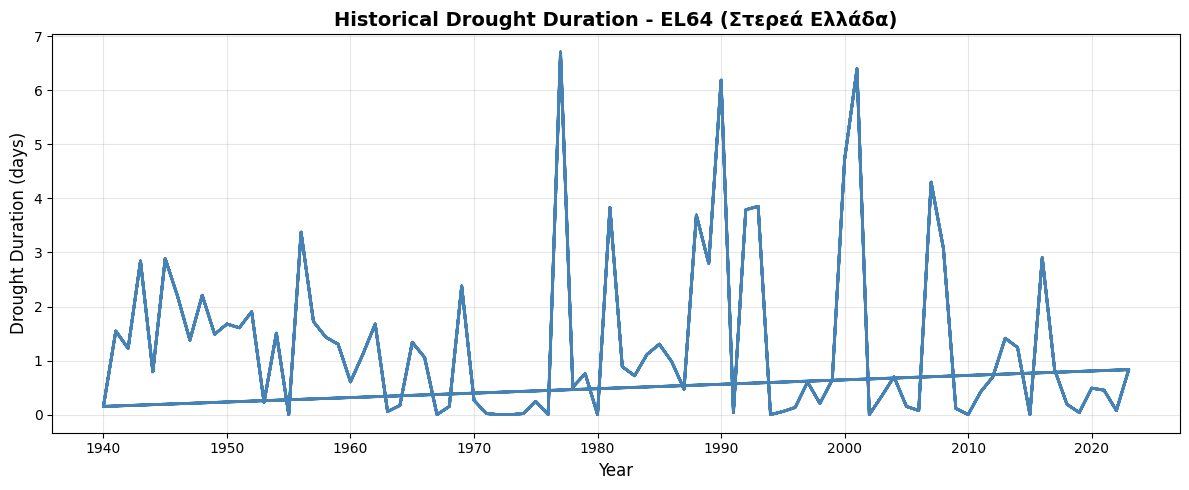


Historical Drought Duration Statistics for EL64:
  Mean: 1.3 days
  Std: 1.5 days
  Min: 0.0 days
  Max: 6.7 days


In [15]:
# Plot historical drought duration timeseries for EL64
if 'drought_dur_hist_el64' in locals():
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Plot the timeseries
    drought_dur_hist_el64['dmd'].plot(ax=ax, linewidth=2, color='steelblue')
    
    ax.set_title(f'Historical Drought Duration - {admin_id} ({sel_gdf["NUTS_NAME"].values[0]})', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Drought Duration (days)', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nHistorical Drought Duration Statistics for {admin_id}:")
    print(f"  Mean: {float(drought_dur_hist_el64['dmd'].mean()):.1f} days")
    print(f"  Std: {float(drought_dur_hist_el64['dmd'].std()):.1f} days")
    print(f"  Min: {float(drought_dur_hist_el64['dmd'].min()):.1f} days")
    print(f"  Max: {float(drought_dur_hist_el64['dmd'].max()):.1f} days")

## Visualize projection drought duration

Now let's visualize the projection data, showing all ensemble members together.

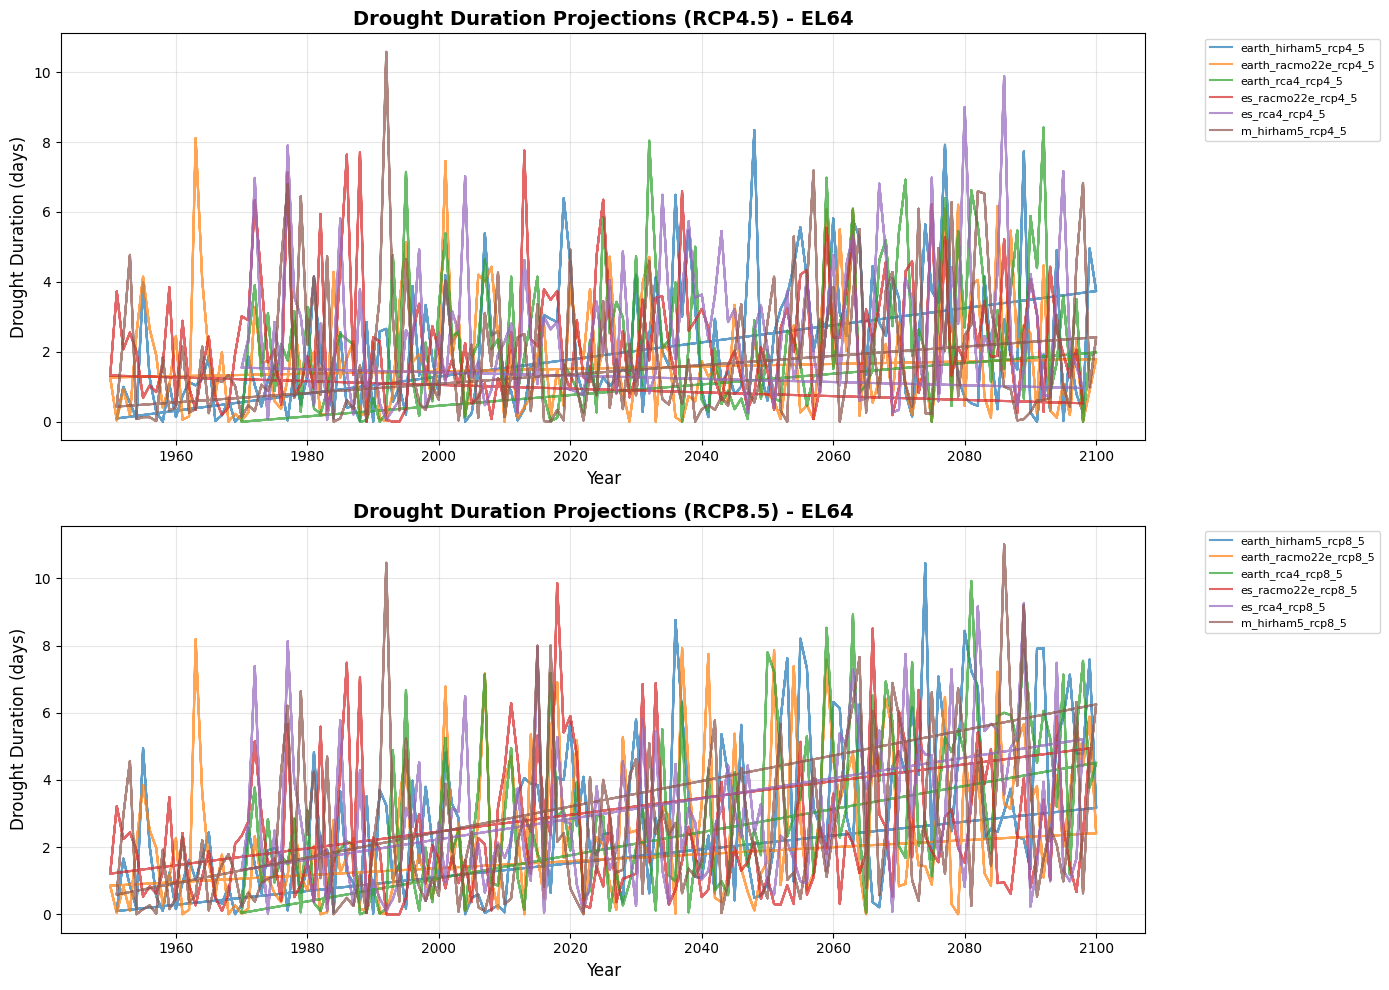


Projection Summary:
  RCP4.5 ensemble members: 6
  RCP8.5 ensemble members: 6


In [16]:
# Plot all projections together
if len(projection_data) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Separate by RCP scenario
    rcp45_models = {k: v for k, v in projection_data.items() if 'rcp4_5' in k}
    rcp85_models = {k: v for k, v in projection_data.items() if 'rcp8_5' in k}
    
    # Plot RCP4.5
    ax = axes[0]
    for model_key, ds in rcp45_models.items():
        ds['dmd'].plot(ax=ax, label=model_key, alpha=0.7, linewidth=1.5)
    
    ax.set_title(f'Drought Duration Projections (RCP4.5) - {admin_id}', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Drought Duration (days)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    # Plot RCP8.5
    ax = axes[1]
    for model_key, ds in rcp85_models.items():
        ds['dmd'].plot(ax=ax, label=model_key, alpha=0.7, linewidth=1.5)
    
    ax.set_title(f'Drought Duration Projections (RCP8.5) - {admin_id}', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Drought Duration (days)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nProjection Summary:")
    print(f"  RCP4.5 ensemble members: {len(rcp45_models)}")
    print(f"  RCP8.5 ensemble members: {len(rcp85_models)}")

/etc/ecmwf/ssd/ssd1/jupyterhub/nejk-jupyterhub/tmpdirs/nejk.27979960/ipykernel_2171019/3864508680.py:26: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(all_data, dim='model', coords='minimal', compat='override')
/etc/ecmwf/ssd/ssd1/jupyterhub/nejk-jupyterhub/tmpdirs/nejk.27979960/ipykernel_2171019/3864508680.py:26: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join expli

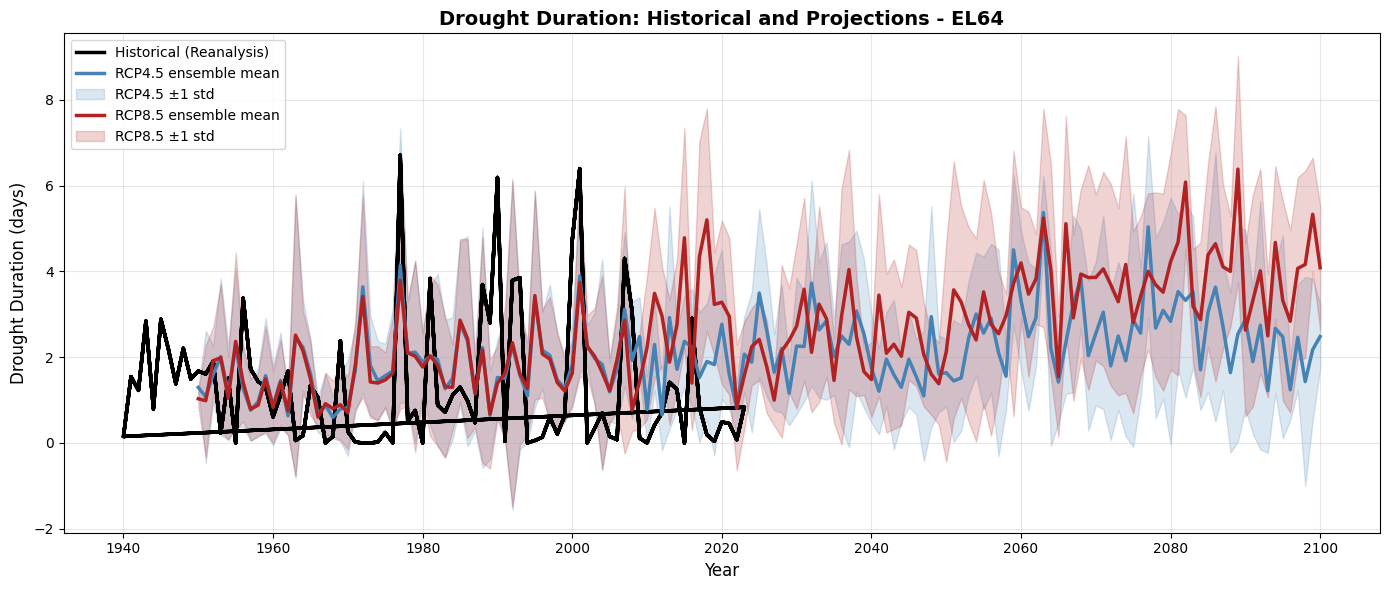

In [18]:
# Calculate and plot ensemble statistics
if len(projection_data) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot historical data
    if 'drought_dur_hist_el64' in locals():
        drought_dur_hist_el64['dmd'].plot(ax=ax, linewidth=2.5, 
                                          color='black', label='Historical (Reanalysis)')
    
    # Calculate ensemble mean and spread for each RCP
    for rcp, color in [('rcp4_5', 'steelblue'), ('rcp8_5', 'firebrick')]:
        rcp_models = {k: v for k, v in projection_data.items() if rcp in k}
        
        if len(rcp_models) > 0:
            # Combine all model data, ensuring unique time coordinates
            all_data = []
            for i, (model_name, ds) in enumerate(rcp_models.items()):
                # Drop duplicates in time dimension if any exist
                da = ds['dmd']
                _, index = np.unique(da['time'], return_index=True)
                da_clean = da.isel(time=sorted(index))
                all_data.append(da_clean)
            
            # Calculate statistics by finding common time coordinates
            # Create a combined dataset aligned on time
            combined = xr.concat(all_data, dim='model', coords='minimal', compat='override')
            mean = combined.mean(dim='model')
            std = combined.std(dim='model')
            p10 = combined.quantile(0.1, dim='model')
            p90 = combined.quantile(0.9, dim='model')
            
            # Plot
            label = f'{rcp.upper().replace("_", ".")} ensemble mean'
            mean.plot(ax=ax, linewidth=2.5, color=color, label=label)
            ax.fill_between(mean.time.values, 
                           (mean - std).values, 
                           (mean + std).values,
                           alpha=0.2, color=color, label=f'{rcp.upper().replace("_", ".")} ±1 std')
    
    ax.set_title(f'Drought Duration: Historical and Projections - {admin_id}', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Drought Duration (days)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()

## Create spatial maps

Let's create maps showing the spatial distribution of drought duration across all NUTS2 regions for selected years.

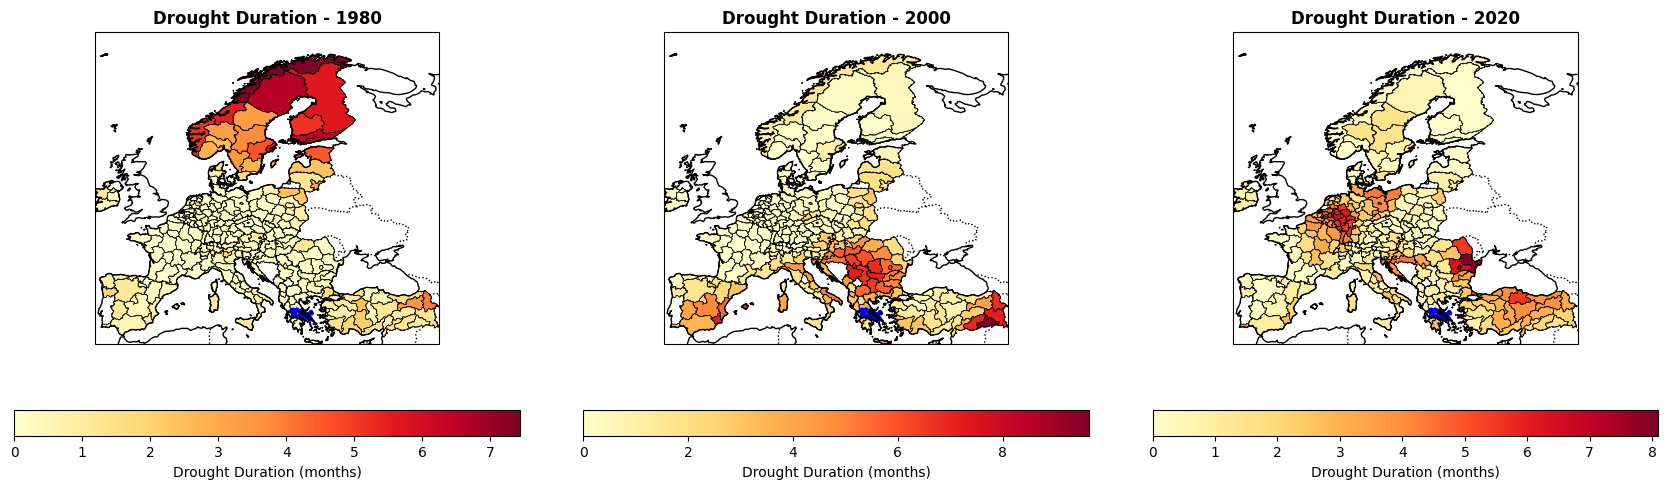

In [21]:
# Plot spatial maps for selected years
if 'drought_dur_hist' in locals():
    # Select years to plot
    years_to_plot = [1980, 2000, 2020]
    available_years = [y for y in years_to_plot if y in drought_dur_hist.time.dt.year.values]
    
    if len(available_years) > 0:
        fig, axes = plt.subplots(1, len(available_years), figsize=(18, 5),
                                subplot_kw={'projection': ccrs.PlateCarree()})
        
        if len(available_years) == 1:
            axes = [axes]
        
        for ax, year in zip(axes, available_years):
            # Select data for the year
            data_year = drought_dur_hist.sel(time=str(year))
            
            # Convert to dataframe and ensure 1D arrays
            year_df = data_year['dmd'].to_dataframe().reset_index()
            
            # Merge with NUTS geometries
            nuts_data = nuts_gdf.merge(
                year_df[['nuts', 'dmd']].rename(columns={'nuts': 'NUTS_ID'}),
                on='NUTS_ID',
                how='left'
            )
            
            # Plot
            nuts_data.plot(column='dmd', ax=ax, legend=True,
                          cmap='YlOrRd', edgecolor='black', linewidth=0.5,
                          legend_kwds={'label': 'Drought Duration (months)',
                                      'orientation': 'horizontal',
                                      'shrink': 0.8})
            
            # Highlight EL64
            sel_gdf.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=3)
            
            ax.coastlines()
            ax.add_feature(cfeature.BORDERS, linestyle=':')
            ax.set_title(f'Drought Duration - {year}', fontsize=12, fontweight='bold')
            ax.set_extent([-10, 45, 35, 72])  # Europe
        
        plt.tight_layout()
        plt.show()

## Save timeseries to CSV files

Finally, we'll save all the timeseries data to CSV files for further analysis.

In [22]:
# Save historical data to CSV
if 'drought_dur_hist_el64' in locals():
    hist_df = drought_dur_hist_el64['dmd'].to_dataframe().reset_index()
    hist_df['scenario'] = 'historical'
    hist_df['model'] = 'reanalysis'
    hist_csv = output_dir / f"drought_duration_historical_{admin_id}.csv"
    hist_df.to_csv(hist_csv, index=False)
    print(f"Saved historical data to: {hist_csv}")
    print(f"  Shape: {hist_df.shape}")
    print(f"  Columns: {list(hist_df.columns)}")

Saved historical data to: data/EL64/drought_hazard/drought_duration_historical_EL64.csv
  Shape: (336, 6)
  Columns: ['time', 'realization', 'nuts', 'dmd', 'scenario', 'model']


In [23]:
# Save projection data to CSV
if len(projection_data) > 0:
    all_proj_data = []
    
    for model_key, ds in projection_data.items():
        # Parse model information
        parts = model_key.split('_')
        gcm = parts[0]
        rcm = parts[1]
        rcp = parts[2] + '_' + parts[3]  # e.g., rcp4_5
        ens = '_'.join(parts[4:])  # e.g., r1i1p1
        
        # Convert to dataframe
        df = ds['dmd'].to_dataframe().reset_index()
        df['scenario'] = rcp
        df['gcm'] = gcm
        df['rcm'] = rcm
        df['ensemble'] = ens
        df['model'] = model_key
        
        all_proj_data.append(df)
    
    # Combine all projection data
    proj_df = pd.concat(all_proj_data, ignore_index=True)
    
    # Save to CSV
    proj_csv = output_dir / f"drought_duration_projections_{admin_id}.csv"
    proj_df.to_csv(proj_csv, index=False)
    print(f"\nSaved projection data to: {proj_csv}")
    print(f"  Shape: {proj_df.shape}")
    print(f"  Columns: {list(proj_df.columns)}")
    print(f"  Unique models: {proj_df['model'].nunique()}")
    print(f"  Scenarios: {proj_df['scenario'].unique()}")


Saved projection data to: data/EL64/drought_hazard/drought_duration_projections_EL64.csv
  Shape: (10340, 8)
  Columns: ['time', 'nuts', 'dmd', 'scenario', 'gcm', 'rcm', 'ensemble', 'model']
  Unique models: 17
  Scenarios: ['rcp4_5' 'rcp8_5' 'wrf381p_rcp4' 'wrf381p_rcp8' 'cclm4_8' 'rca4_rcp4'
 'rca4_rcp8']


In [24]:
# Create a combined CSV with both historical and projections
if 'hist_df' in locals() and 'proj_df' in locals():
    # Align columns
    common_cols = ['time', 'nuts', 'dmd', 'scenario', 'model']
    
    hist_df_clean = hist_df[common_cols].copy()
    proj_df_clean = proj_df[['time', 'nuts', 'dmd', 'scenario', 'model']].copy()
    
    combined_df = pd.concat([hist_df_clean, proj_df_clean], ignore_index=True)
    combined_df = combined_df.sort_values('time').reset_index(drop=True)
    
    combined_csv = output_dir / f"drought_duration_all_{admin_id}.csv"
    combined_df.to_csv(combined_csv, index=False)
    print(f"\nSaved combined data to: {combined_csv}")
    print(f"  Shape: {combined_df.shape}")
    print(f"  Time range: {combined_df['time'].min()} to {combined_df['time'].max()}")


Saved combined data to: data/EL64/drought_hazard/drought_duration_all_EL64.csv
  Shape: (10676, 5)
  Time range: 1940-01-01 00:00:00 to 2100-01-01 00:00:00


## Summary

This notebook has demonstrated a complete workflow for:
1. ✅ Downloading historical drought duration data from ECDE using CDSAPI
2. ✅ Downloading projection drought duration data for multiple model combinations
3. ✅ Reading and processing the data for region EL64 (Central Greece)
4. ✅ Visualizing drought timeseries for historical and projection data
5. ✅ Creating spatial maps of drought duration
6. ✅ Saving all timeseries data to CSV files

**Output files created:**
- `drought_duration_historical_{admin_id}.csv` - Historical drought duration
- `drought_duration_projections_{admin_id}.csv` - All projection ensemble members
- `drought_duration_all_{admin_id}.csv` - Combined historical and projections

These CSV files can now be used for further analysis, risk assessment, or integration with exposure and vulnerability data.